# 06c - SHAP Local Explanations
Lokalni vysvetleni pro konkretni studenty — proc model predikoval prave takto.

- **Waterfall plot** — jak jednotlive featury posunuly predikci od globalniho prumeru k finalnimu skore
- **Force plot** — kompaktni verze vhodna pro prezentace
- **Porovnani rizikoveho vs bezpecneho studenta** — co je odlisuje z pohledu modelu

In [1]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

ctx          = joblib.load('../results/xai/xai_context.pkl')
shap_all     = joblib.load('../results/xai/shap_values_all.pkl')

X_test_prep   = ctx['X_test_prep']
y_test        = ctx['y_test']
tuned_models  = ctx['tuned_models']
winning_name  = ctx['winning_name']
probabilities = ctx['probabilities']
student_index = ctx['student_index']
risky_student = ctx['risky_student']
student_prob  = ctx['student_prob']


# shap_single: bezpecne indexovani jednoho studenta z SHAP objektu.
# Resí problem kdy base_values zustane shape (2,) i po normalize_shap —
# ke kteremu dochazi pokud byl pkl ulozen se starymi 3D hodnotami.
def shap_single(shap_vals, idx):
    sv = shap_vals[idx]
    # values: pokud je stale 2D (zbytek po indexovani 3D objektu), vezmeme tridu 1
    if np.ndim(sv.values) == 2:
        sv.values = sv.values[:, 1]
    # base_values: pokud je array misto skalaru, vezmeme tridu 1
    if np.ndim(sv.base_values) > 0:
        sv.base_values = float(sv.base_values[1] if len(sv.base_values) > 1 else sv.base_values[0])
    return sv

shap_values_best = shap_all[winning_name]
print(f"Vitezny model: {winning_name}")

print(f"Vitezny model: {winning_name}")
print(f"Rizikovy student: index {student_index}, predikce {student_prob:.1%}")

import matplotlib as _mpl

# Paul Tol bright palette — colorblind-safe, perceptually uniform
_PALETTE = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377', '#BBBBBB']

_mpl.rcParams.update({
    # Color cycle
    'axes.prop_cycle':       _mpl.cycler(color=_PALETTE),

    # Backgrounds
    'figure.facecolor':      'white',
    'axes.facecolor':        '#F8F9FA',   # subtle off-white — "card" feel

    # Spines
    'axes.edgecolor':        '#DEE2E6',
    'axes.linewidth':        0.9,
    'axes.spines.top':       False,
    'axes.spines.right':     False,

    # Grid — solid, very light
    'axes.grid':             True,
    'axes.axisbelow':        True,
    'grid.color':            '#E9ECEF',
    'grid.linestyle':        '-',
    'grid.linewidth':        0.8,
    'grid.alpha':            1.0,

    # Typography
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'axes.titlesize':        14,
    'axes.titleweight':      'bold',
    'axes.titlepad':         14,
    'axes.labelsize':        12,
    'axes.labelweight':      'regular',
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       10,
    'legend.title_fontsize': 11,
    'figure.titlesize':      16,
    'figure.titleweight':    'bold',

    # Text colors — near-black for contrast
    'text.color':            '#212529',
    'axes.labelcolor':       '#495057',
    'xtick.color':           '#495057',
    'ytick.color':           '#495057',

    # Ticks
    'xtick.direction':       'out',
    'ytick.direction':       'out',
    'xtick.major.size':      4,
    'ytick.major.size':      4,
    'xtick.minor.visible':   False,
    'ytick.minor.visible':   False,
    'xtick.major.pad':       5,
    'ytick.major.pad':       5,

    # Lines & markers
    'lines.linewidth':       2.0,
    'lines.markersize':      7,
    'patch.linewidth':       0.6,

    # Legend
    'legend.frameon':        True,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#DEE2E6',
    'legend.fancybox':       True,
    'legend.borderpad':      0.6,

    # Figure / saving
    'figure.dpi':            100,
    'figure.figsize':        [8, 5],
    'savefig.dpi':           150,
    'savefig.bbox':          'tight',
    'savefig.facecolor':     'white',
    'savefig.edgecolor':     'none',
})


Vitezny model: Logistic Regression
Vitezny model: Logistic Regression
Rizikovy student: index 16, predikce 80.8%


## Waterfall plot — rozpad rizika rizikového studenta
Zobrazuje, jak kazda featura posunula skore tohoto studenta od prumeru az k jeho finale.

SHAP Waterfall: Logistic Regression — student c. 16 (80.8%)


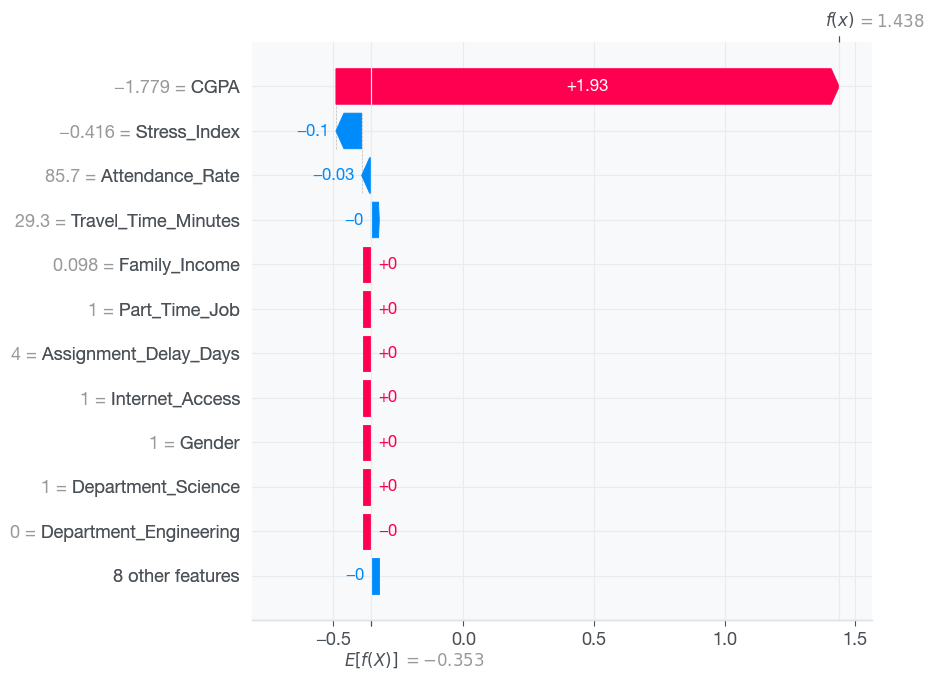

In [2]:
print(f"SHAP Waterfall: {winning_name} — student c. {student_index} ({student_prob:.1%})")
shap.plots.waterfall(shap_values_best[student_index], max_display=12)

## Force plot — kompaktní vizualizace

In [3]:
from shap import initjs

print(f"SHAP Force Plot: {winning_name} — student c. {student_index}")
initjs()
shap.plots.force(shap_values_best[student_index])

SHAP Force Plot: Logistic Regression — student c. 16


## Waterfall pro všechny 3 modely — stejný student
Ukazuje, zda vsechny modely vidí stejne featury jako klicove pro tohoto studenta.


  Waterfall: Logistic Regression — student c. 16 (80.8%)


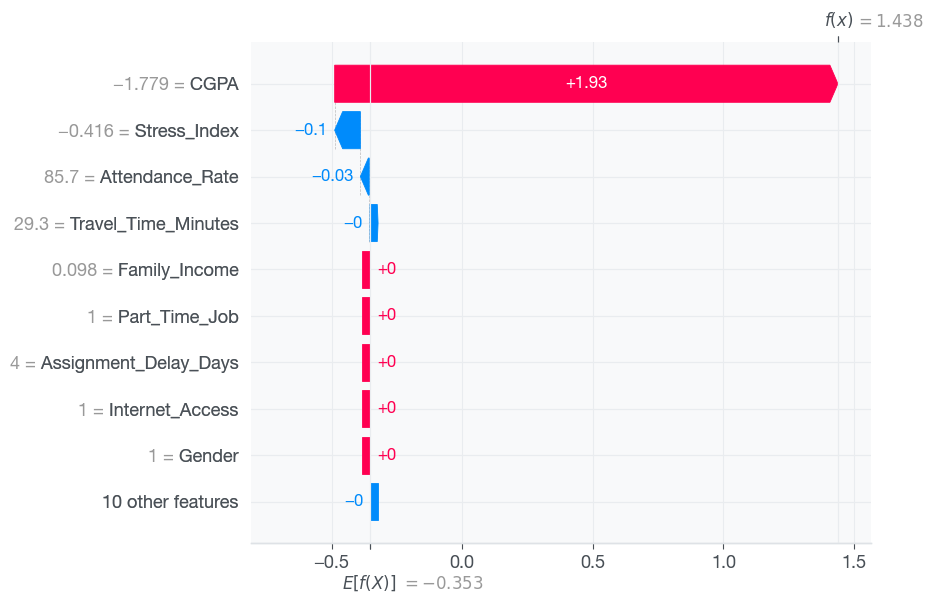


  Waterfall: Random Forest — student c. 16 (80.8%)


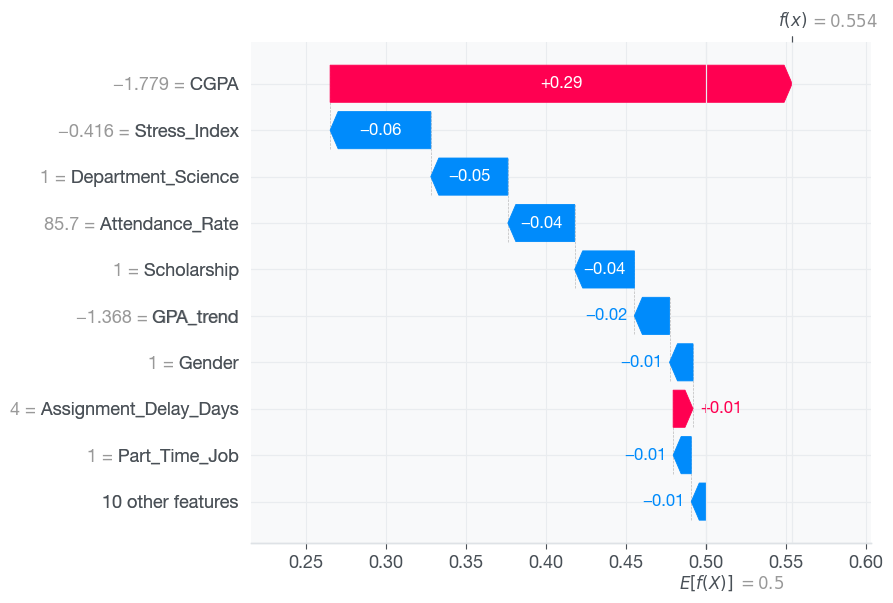


  Waterfall: Gradient Boosting — student c. 16 (80.8%)


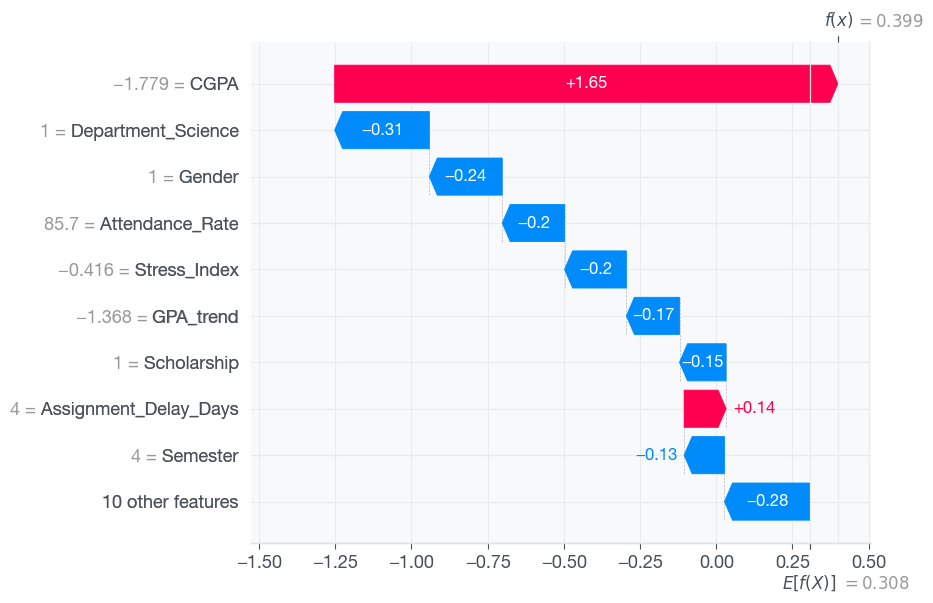


  Waterfall: Decision Tree — student c. 16 (80.8%)


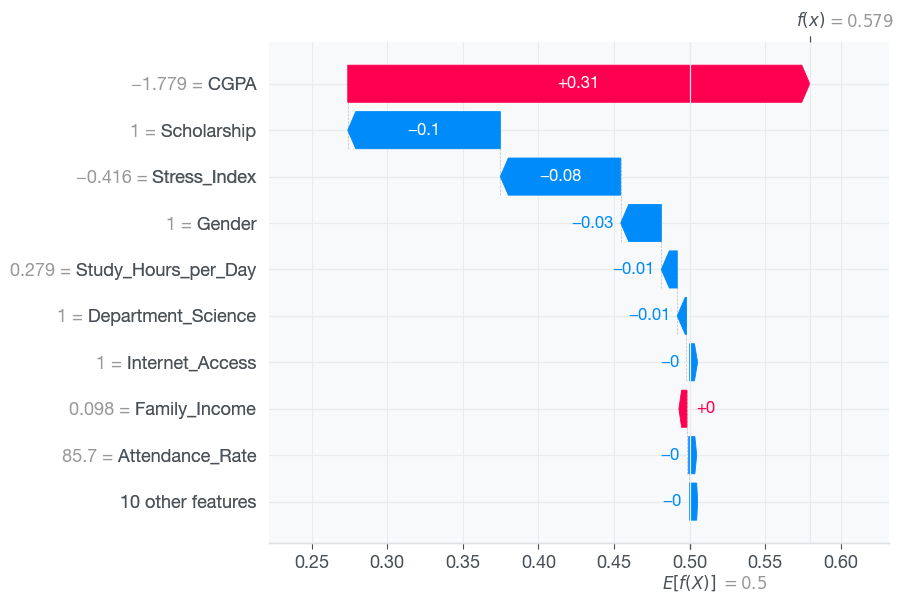

In [4]:
for name, shap_vals in shap_all.items():
    print(f"\n{'=' * 55}")
    print(f"  Waterfall: {name} — student c. {student_index} ({student_prob:.1%})")
    print(f"{'=' * 55}")
    shap.plots.waterfall(shap_single(shap_vals, student_index), max_display=10)

## Porovnání: rizikový vs. bezpečný student
Vybereme studenta s velmi nizkym rizikem a porovname, co model vidi jinak.

Bezpecny student: index 6, predikce 9.0%
Rizikovy student: index 16, predikce 80.8%


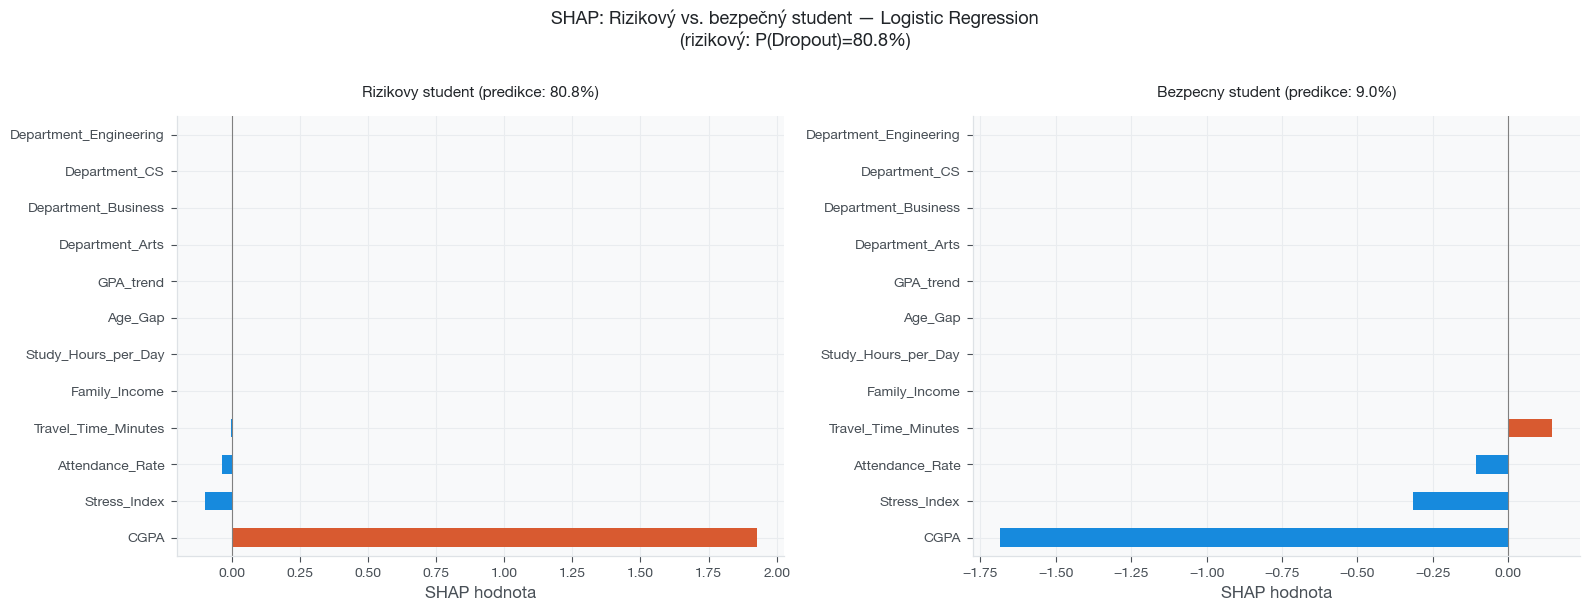

In [5]:
safe_indices = [i for i, p in enumerate(probabilities) if p < 0.10]
safe_index   = safe_indices[0]
safe_prob    = probabilities[safe_index]

print(f"Bezpecny student: index {safe_index}, predikce {safe_prob:.1%}")
print(f"Rizikovy student: index {student_index}, predikce {student_prob:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'SHAP: Rizikový vs. bezpečný student — {winning_name}\n'
    f'(rizikový: P(Dropout)={student_prob:.1%})',
    fontsize=13, fontweight='bold', y=1.01
)

# SHAP hodnoty jako bar chart pro oba studenty
shap_risky = pd.Series(shap_values_best.values[student_index], index=X_test_prep.columns)
shap_safe  = pd.Series(shap_values_best.values[safe_index],    index=X_test_prep.columns)

# Sjednotime poradi featur podle absolutni dulezitosti pro rizikoveho studenta
top_feats = shap_risky.abs().nlargest(12).index

colors_risky = ['#D85A30' if v > 0 else '#178ADD' for v in shap_risky[top_feats]]
colors_safe  = ['#D85A30' if v > 0 else '#178ADD' for v in shap_safe[top_feats]]

shap_risky[top_feats].plot(kind='barh', ax=axes[0], color=colors_risky)
axes[0].set_title(f'Rizikovy student (predikce: {student_prob:.1%})', fontsize=11)
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_xlabel('SHAP hodnota')

shap_safe[top_feats].plot(kind='barh', ax=axes[1], color=colors_safe)
axes[1].set_title(f'Bezpecny student (predikce: {safe_prob:.1%})', fontsize=11)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('SHAP hodnota')

plt.tight_layout()
plt.show()

## Klasifikace vybrané instance všemi modely
Explicitni odpoved na otazky zadani:
- Predikuji vsechny modely stejnou tridu?
- Jaka je spolehlivost (pravdepodobnost) predikce?

*(Podrobna vizualizace s Decision Tree je v `06f-decision-tree-explanation.ipynb`)*

In [6]:
import pandas as pd

skutecna_trida = int(y_test.iloc[student_index])
rows = []

for name, model in tuned_models.items():
    pred  = int(model.predict(risky_student.values.reshape(1, -1))[0])
    proba = model.predict_proba(risky_student.values.reshape(1, -1))[0]
    rows.append({
        'Model':            name,
        'Predikce':         'Dropout (1)' if pred == 1 else 'Dostuduje (0)',
        'P(Dropout)':       f"{proba[1]:.1%}",
        'P(Dostuduje)':     f"{proba[0]:.1%}",
        'Shoda s LR':       'ANO' if (pred == 1) == (winning_name == name or True) else 'NE',
        'Spravna predikce': 'ANO' if pred == skutecna_trida else 'NE',
    })

# Přepočítáme shodu — porovnáváme se skutečnou predikcí vítěze
vitez_pred = int(tuned_models[winning_name].predict(risky_student.values.reshape(1, -1))[0])
for row in rows:
    pred_int = 1 if '1' in row['Predikce'] else 0
    row['Shoda s vitezem'] = 'ANO' if pred_int == vitez_pred else 'NE'
    del row['Shoda s LR']

df_compare = pd.DataFrame(rows)
print(f"Vybrana instance: student c. {student_index} (index v testovaci sade)")
print(f"Skutecna trida:   {'Dropout (1)' if skutecna_trida == 1 else 'Dostuduje (0)'}")
print(f"{'=' * 70}")
print(df_compare.to_string(index=False))

# Shodují se všechny modely?
predikce = [1 if '1' in r['Predikce'] else 0 for r in rows]
if len(set(predikce)) == 1:
    print(f"\nVSECHNY modely se shoduji: {'Dropout (1)' if predikce[0] == 1 else 'Dostuduje (0)'}")
else:
    print(f"\nModely se NESHODUJI — ruzne predikce pro tuto instanci.")

Vybrana instance: student c. 16 (index v testovaci sade)
Skutecna trida:   Dostuduje (0)
              Model    Predikce P(Dropout) P(Dostuduje) Spravna predikce Shoda s vitezem
Logistic Regression Dropout (1)      80.8%        19.2%               NE             ANO
      Random Forest Dropout (1)      55.4%        44.6%               NE             ANO
  Gradient Boosting Dropout (1)      59.8%        40.2%               NE             ANO
      Decision Tree Dropout (1)      57.9%        42.1%               NE             ANO

VSECHNY modely se shoduji: Dropout (1)


/Users/janvrzal/Documents/Uni/Zpracování informací a znalostí/student dropout/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/janvrzal/Documents/Uni/Zpracování informací a znalostí/student dropout/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/janvrzal/Documents/Uni/Zpracování informací a znalostí/student dropout/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/janvrzal/Documents/Uni/Zpracování informací a znalostí/student dropout/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have val